# FL vs SFL — Non-IID MNIST with Model Poisoning Attack

This notebook extends the baseline **FL vs SFL non-IID label-skew experiment** by adding a simple **model poisoning attack** from one malicious client.

The notebook runs two scenarios:

1. **Baseline:** all clients are honest.
2. **Attack:** one malicious client trains normally, but reverses and scales its model update before aggregation.

For each scenario, the notebook compares **Federated Learning (FL)** and **Split Federated Learning (SFL Design 1)** under 1, 2, 4, and 6 labels per client. The global model is evaluated after every communication round.

## 1. Import libraries

This cell imports the Python, PyTorch, TorchVision, NumPy, Pandas, and plotting libraries used in the experiment.


In [1]:
import os
import copy
import time
import random
from collections import OrderedDict, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms


## 2. Reproducibility and device setup

This cell fixes random seeds so that repeated runs are easier to compare. It also selects GPU if CUDA is available, otherwise CPU.


In [2]:
def set_seed(seed: int = 42):
    """Set random seeds for Python, NumPy, and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # These settings help make CUDA results more deterministic.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 3. Experiment settings, attack settings, and output folders

This cell controls the whole experiment.

Important settings:

- `LABELS_PER_CLIENT_LIST = [1, 2, 4, 6]` controls the non-IID severity.
- `RUN_BASELINE = True` runs the normal no-attack case.
- `RUN_ATTACK = True` runs the malicious-client model-poisoning case.
- `MALICIOUS_CLIENT_ID = 0` means client 0 is the attacker.
- `ATTACK_SCALE = -5.0` means the attacker sends the opposite of its true update, magnified by 5.

The weights, CSV files, plots, and report text are saved into separate folders so the baseline and attacked results are easy to compare.

In [25]:
# MNIST has 10 digit classes, so 10 clients works naturally for label-skew experiments.
NUM_CLIENTS = 10
ROUNDS = 50
LOCAL_EPOCHS = 1
BATCH_SIZE = 64
TEST_BATCH_SIZE = 256

# Run these non-IID severities. 1 label/client is the hardest case.
LABELS_PER_CLIENT_LIST = [1, 2, 4, 6]

# Optimizer settings.
# Use "sgd" or "adam". Adam is useful to compare when SGD struggles under non-IID data.
OPTIMIZER_NAME = "SGD"
LEARNING_RATE = 0.005

# Optional learning-rate decay.
# For SGD, you might want to experiment with this to improve convergence.
USE_LR_DECAY = False
LR_DECAY = 0.98


def get_round_lr(round_id: int) -> float:
    """Return the learning rate for this communication round."""
    if USE_LR_DECAY:
        # Decay the learning rate slowly after each communication round.
        return LEARNING_RATE * (LR_DECAY ** (round_id - 1))
    return LEARNING_RATE


# Set to an integer such as 1000 for a quick debugging run.
# Set to None for the full MNIST training set.
MAX_SAMPLES_PER_CLIENT = None

# Save weights every N rounds. Use 1 to save every round, or 10 to save fewer files.
SAVE_WEIGHTS_EVERY = 1

# -------------------------
# Poisoning attack settings
# -------------------------
RUN_BASELINE = True
RUN_ATTACK = True
MALICIOUS_CLIENT_ID = 0
ATTACK_SCALE = -5.0

# Explanation:
# Honest client sends: global_model + true_update
# Malicious client sends: global_model + ATTACK_SCALE * true_update
# With ATTACK_SCALE = -5.0, the malicious client pushes the model in the opposite direction.

RESULTS_CSV_DIR = "results/csv"
PLOTS_DIR = "results/plots"
WEIGHTS_BASE_DIR = "results/weights/fl_vs_sfl_noniid_poisoning_attack"
REPORT_DIR = "results/reports"

os.makedirs(RESULTS_CSV_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(WEIGHTS_BASE_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print("CSV results will be saved to:", RESULTS_CSV_DIR)
print("Plots will be saved to:", PLOTS_DIR)
print("Weights will be saved under:", WEIGHTS_BASE_DIR)
print("Report text will be saved to:", REPORT_DIR)

CSV results will be saved to: results/csv
Plots will be saved to: results/plots
Weights will be saved under: results/weights/fl_vs_sfl_noniid_poisoning_attack
Report text will be saved to: results/reports


## 4. Load MNIST dataset

This cell downloads MNIST if it is not already available in `./data`. The images are converted to PyTorch tensors.


In [26]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


Train samples: 60000
Test samples: 10000


## 5. Create non-IID client datasets

This cell creates the key label-skew partition.

Important design choice: **samples are not duplicated** between clients. For example, if `labels_per_client = 2`, a digit class may appear in two clients, but the samples of that digit are split between those clients.


In [27]:
def get_targets(dataset):
    """Return all labels/targets from a TorchVision dataset."""
    if hasattr(dataset, "targets"):
        targets = dataset.targets
        if torch.is_tensor(targets):
            targets = targets.cpu().numpy()
        return np.array(targets)
    return np.array([dataset[i][1] for i in range(len(dataset))])


def build_cyclic_client_label_map(num_clients: int, unique_labels, labels_per_client: int):
    """Assign each client a cyclic set of labels.

    Example for MNIST and labels_per_client=2:
    client 0 -> [0, 1]
    client 1 -> [1, 2]
    ...
    client 9 -> [9, 0]
    """
    labels = list(unique_labels)
    num_labels = len(labels)

    if labels_per_client < 1 or labels_per_client > num_labels:
        raise ValueError("labels_per_client must be between 1 and the number of classes.")

    client_label_map = {}
    for client_id in range(num_clients):
        # Cyclic assignment keeps all clients similarly non-IID.
        client_label_map[client_id] = [labels[(client_id + j) % num_labels] for j in range(labels_per_client)]

    return client_label_map


def create_label_skew_client_subsets(dataset, num_clients: int, labels_per_client: int, seed: int, max_samples_per_client=None):
    """Create non-IID client subsets with a fixed number of labels per client.

    The function first decides which labels each client should receive. Then, for each label,
    it splits that label's samples across all clients that contain that label. This avoids
    duplicate training samples across clients.
    """
    targets = get_targets(dataset)
    unique_labels = sorted(np.unique(targets).tolist())
    rng = np.random.default_rng(seed + labels_per_client * 100)

    client_label_map = build_cyclic_client_label_map(num_clients, unique_labels, labels_per_client)

    # Reverse map: label -> clients that should receive part of this label's data.
    label_to_clients = defaultdict(list)
    for client_id, labels in client_label_map.items():
        for label in labels:
            label_to_clients[label].append(client_id)

    client_indices = {client_id: [] for client_id in range(num_clients)}

    for label in unique_labels:
        label_indices = np.where(targets == label)[0]
        rng.shuffle(label_indices)

        receiving_clients = label_to_clients[label]
        # Split this label's samples across the clients assigned to this label.
        split_indices = np.array_split(label_indices, len(receiving_clients))

        for client_id, part in zip(receiving_clients, split_indices):
            client_indices[client_id].extend(part.tolist())

    subsets = []
    for client_id in range(num_clients):
        indices = np.array(client_indices[client_id])
        rng.shuffle(indices)

        # Optional cap for quick testing. Leave as None for full experiments.
        if max_samples_per_client is not None:
            indices = indices[:max_samples_per_client]

        subsets.append(Subset(dataset, indices.tolist()))

    return subsets, client_label_map


def describe_client_split(client_subsets, client_label_map):
    """Print a compact summary of labels and sample counts per client."""
    for client_id, subset in enumerate(client_subsets):
        print(
            f"Client {client_id + 1:02d}: "
            f"labels={client_label_map[client_id]}, samples={len(subset)}"
        )
    print("Total samples used:", sum(len(subset) for subset in client_subsets))


## 6. Data loaders

This cell creates deterministic loaders. FL and SFL use the same batch order for the same client and round, which helps test whether the FL and SFL implementations are equivalent.


In [28]:
def make_client_loader(client_subsets, client_id: int, round_id: int):
    """Create one DataLoader for one client in one communication round."""
    # Same seed for FL and SFL means both methods see batches in the same order.
    loader_seed = SEED + round_id * 1000 + client_id
    generator = torch.Generator().manual_seed(loader_seed)

    return DataLoader(
        client_subsets[client_id],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )


test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
)


## 7. Define the full model and split model

The full FL model and the combined SFL client/server model have the same architecture. This is important because we want to compare FL and SFL fairly.


In [29]:
class FullModel(nn.Module):
    """Full model used by FL and reconstructed SFL evaluation."""
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 64)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(64, 32)
        self.relu4 = nn.ReLU()
        self.fc5 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.relu4(self.fc4(x))
        return self.fc5(x)


class ClientModel(nn.Module):
    """SFL client-side model: first part of the full neural network."""
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        return self.relu2(self.fc2(x))


class ServerModel(nn.Module):
    """SFL server-side model: second part of the full neural network."""
    def __init__(self):
        super().__init__()
        self.fc3 = nn.Linear(128, 64)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(64, 32)
        self.relu4 = nn.ReLU()
        self.fc5 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.relu3(self.fc3(x))
        x = self.relu4(self.fc4(x))
        return self.fc5(x)


## 8. State-dictionary helper functions

These helper functions convert between the full FL model and the split SFL client/server models. They also implement FedAvg and the L2 distance check between FL and reconstructed SFL weights.


In [30]:
def get_state_dict(model: nn.Module):
    """Return a CPU copy of the model parameters."""
    return OrderedDict((k, v.detach().cpu().clone()) for k, v in model.state_dict().items())


def load_state_dict_to_model(model: nn.Module, state_dict):
    """Load a saved state dictionary into a model."""
    model.load_state_dict(state_dict, strict=True)


def full_to_client_state(full_state):
    """Extract the SFL client-side weights from the full model."""
    return OrderedDict({
        "fc1.weight": full_state["fc1.weight"].clone(),
        "fc1.bias": full_state["fc1.bias"].clone(),
        "fc2.weight": full_state["fc2.weight"].clone(),
        "fc2.bias": full_state["fc2.bias"].clone(),
    })


def full_to_server_state(full_state):
    """Extract the SFL server-side weights from the full model."""
    return OrderedDict({
        "fc3.weight": full_state["fc3.weight"].clone(),
        "fc3.bias": full_state["fc3.bias"].clone(),
        "fc4.weight": full_state["fc4.weight"].clone(),
        "fc4.bias": full_state["fc4.bias"].clone(),
        "fc5.weight": full_state["fc5.weight"].clone(),
        "fc5.bias": full_state["fc5.bias"].clone(),
    })


def split_to_full_state(client_state, server_state):
    """Reconstruct a full-model state dictionary from SFL client and server parts."""
    full_state = OrderedDict()
    full_state["fc1.weight"] = client_state["fc1.weight"].clone()
    full_state["fc1.bias"] = client_state["fc1.bias"].clone()
    full_state["fc2.weight"] = client_state["fc2.weight"].clone()
    full_state["fc2.bias"] = client_state["fc2.bias"].clone()
    full_state["fc3.weight"] = server_state["fc3.weight"].clone()
    full_state["fc3.bias"] = server_state["fc3.bias"].clone()
    full_state["fc4.weight"] = server_state["fc4.weight"].clone()
    full_state["fc4.bias"] = server_state["fc4.bias"].clone()
    full_state["fc5.weight"] = server_state["fc5.weight"].clone()
    full_state["fc5.bias"] = server_state["fc5.bias"].clone()
    return full_state


def fedavg_state_dicts(state_dicts, sample_counts):
    """Weighted FedAvg aggregation using each client's number of samples."""
    total_samples = sum(sample_counts)
    avg_state = OrderedDict()

    for key in state_dicts[0].keys():
        avg_tensor = torch.zeros_like(state_dicts[0][key], dtype=torch.float32)
        for state, n in zip(state_dicts, sample_counts):
            # Weight each client update by its local dataset size.
            avg_tensor += state[key].float() * (n / total_samples)
        avg_state[key] = avg_tensor

    return avg_state


def l2_distance_state_dicts(state_a, state_b):
    """Calculate L2 distance between two model state dictionaries."""
    total_sq = 0.0
    for key in state_a.keys():
        diff = state_a[key].float() - state_b[key].float()
        total_sq += torch.sum(diff ** 2).item()
    return total_sq ** 0.5


## 9. Optimizer helper

This cell lets the same notebook switch between SGD and Adam without rewriting the training functions.


In [31]:
def make_optimizer(parameters, optimizer_name: str, lr: float):
    """Create an optimizer using the selected optimizer name."""
    optimizer_name = optimizer_name.lower()

    if optimizer_name == "sgd":
        return optim.SGD(parameters, lr=lr)

    if optimizer_name == "adam":
        return optim.Adam(parameters, lr=lr)

    raise ValueError("optimizer_name must be either 'sgd' or 'adam'.")


## 10. Evaluation function

This function evaluates the global model on the full MNIST test set after every aggregation round.


In [32]:
@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, device: torch.device):
    """Return average test loss and test accuracy."""
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


## 11. FL client training

Each FL client receives a copy of the global full model, trains locally, and returns the updated full-model weights.


In [33]:
def train_fl_client(start_global_state, train_loader: DataLoader, local_epochs: int, lr: float, device: torch.device):
    """Train one FL client for the configured number of local epochs."""
    model = FullModel().to(device)
    load_state_dict_to_model(model, start_global_state)

    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model.parameters(), OPTIMIZER_NAME, lr)

    for _ in range(local_epochs):
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    return get_state_dict(model)


## 12. SFL Design 1 client training

This uses the equivalence-focused SFL design: each client has its own client-side model and its own independent server-side copy during the round. After local training, the client-side and server-side states are aggregated separately.


In [34]:
def train_sfl_client_design1(start_client_state, start_server_state, train_loader: DataLoader, local_epochs: int, lr: float, device: torch.device):
    """Train one SFL Design 1 client/server pair."""
    client_model = ClientModel().to(device)
    server_model = ServerModel().to(device)

    load_state_dict_to_model(client_model, start_client_state)
    load_state_dict_to_model(server_model, start_server_state)

    client_model.train()
    server_model.train()

    criterion = nn.CrossEntropyLoss()
    client_optimizer = make_optimizer(client_model.parameters(), OPTIMIZER_NAME, lr)
    server_optimizer = make_optimizer(server_model.parameters(), OPTIMIZER_NAME, lr)

    for _ in range(local_epochs):
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            client_optimizer.zero_grad()
            server_optimizer.zero_grad()

            # Forward pass on the client-side model.
            smashed_data = client_model(x)

            # Detach smashed data to simulate the cut layer between client and server.
            smashed_data_detached = smashed_data.detach().requires_grad_(True)

            # Forward and backward pass on the server-side model.
            logits = server_model(smashed_data_detached)
            loss = criterion(logits, y)
            loss.backward()

            # Send gradient at the cut layer back to the client-side model.
            grad_to_client = smashed_data_detached.grad.clone()
            server_optimizer.step()

            # Backpropagate into the client-side model using the received gradient.
            smashed_data.backward(grad_to_client)
            client_optimizer.step()

    return get_state_dict(client_model), get_state_dict(server_model)


## 13. Model poisoning helper function

This cell implements the malicious update.

The attack is applied **after local training** and **before FedAvg aggregation**:

1. The malicious client receives the global model.
2. It trains locally like an honest client.
3. It computes the local update: `client_state - global_state`.
4. It sends a poisoned version: `global_state + attack_scale × update`.

With `attack_scale = -5`, the client reverses the direction of its update and magnifies it by five. This is a simple but useful first poisoning attack because the client still appears to participate normally, but its submitted update damages the global aggregation step.

In [35]:
def poison_model_update(global_state, client_state, attack_scale: float):
    """Return a poisoned client state using scaled model-update poisoning.

    Normal local update:
        update = client_state - global_state

    Poisoned submitted state:
        poisoned_state = global_state + attack_scale * update

    If attack_scale is negative, the malicious client pushes the global model in the
    opposite direction of honest learning. If the magnitude is greater than 1, the
    malicious effect is amplified.
    """
    poisoned_state = OrderedDict()

    for key in global_state.keys():
        # Calculate the client's true local update for this parameter tensor.
        true_update = client_state[key].float() - global_state[key].float()

        # Replace the honest submitted state with a harmful scaled update.
        poisoned_state[key] = global_state[key].float() + attack_scale * true_update

    return poisoned_state


def scenario_name(attack_enabled: bool, attack_scale: float = ATTACK_SCALE) -> str:
    """Create a clean scenario name for filenames and tables."""
    if not attack_enabled:
        return "baseline_no_attack"

    # Make the attack scale safe to use in filenames.
    safe_scale = str(attack_scale).replace("-", "minus_").replace(".", "p")
    return f"attack_client_{MALICIOUS_CLIENT_ID}_scale_{safe_scale}"


## 14. Run one FL vs SFL experiment for one scenario

This function runs one complete experiment for one label-skew setting and one scenario.

For example:

- 2 labels/client with no attack
- 2 labels/client with client 0 poisoning the update

The key attack lines are inside the client loops. The malicious client trains normally first, then the notebook applies `poison_model_update(...)` before the client state is added to the aggregation list.

In [36]:
def run_fl_vs_sfl_experiment(labels_per_client: int, attack_enabled: bool):
    """Run FL and SFL for one labels-per-client setting and one attack scenario."""
    scen = scenario_name(attack_enabled)

    print("\n" + "=" * 90)
    print(f"Starting experiment: labels_per_client={labels_per_client} | scenario={scen}")
    print("=" * 90)

    # Create a fresh non-IID split for this severity level.
    client_subsets, client_label_map = create_label_skew_client_subsets(
        train_dataset,
        num_clients=NUM_CLIENTS,
        labels_per_client=labels_per_client,
        seed=SEED,
        max_samples_per_client=MAX_SAMPLES_PER_CLIENT,
    )
    describe_client_split(client_subsets, client_label_map)

    sample_counts = [len(subset) for subset in client_subsets]

    # Each label setting and scenario gets its own weight folder.
    exp_tag = f"labels_{labels_per_client}_per_client/{scen}"
    weights_dir = os.path.join(WEIGHTS_BASE_DIR, exp_tag)
    os.makedirs(weights_dir, exist_ok=True)

    # Start FL and SFL from identical initial weights for fair comparison.
    set_seed(SEED)
    initial_full_model = FullModel()
    initial_full_state = get_state_dict(initial_full_model)

    fl_global_state = copy.deepcopy(initial_full_state)
    sfl_global_client_state = full_to_client_state(initial_full_state)
    sfl_global_server_state = full_to_server_state(initial_full_state)

    results = []

    for round_id in range(1, ROUNDS + 1):
        current_lr = get_round_lr(round_id)
        print(
            f"\n--- labels/client={labels_per_client} | scenario={scen} | "
            f"round {round_id}/{ROUNDS} | lr={current_lr:.6f} ---"
        )
        round_start_time = time.perf_counter()

        # -------------------------
        # FL local training
        # -------------------------
        fl_start_time = time.perf_counter()
        fl_client_states = []

        for client_id in range(NUM_CLIENTS):
            # One loader per client is needed because each client owns a different local dataset.
            loader = make_client_loader(client_subsets, client_id, round_id)

            trained_state = train_fl_client(
                start_global_state=fl_global_state,
                train_loader=loader,
                local_epochs=LOCAL_EPOCHS,
                lr=current_lr,
                device=device,
            )

            # Apply poisoning only to the selected malicious client and only in the attack scenario.
            if attack_enabled and client_id == MALICIOUS_CLIENT_ID:
                trained_state = poison_model_update(
                    global_state=fl_global_state,
                    client_state=trained_state,
                    attack_scale=ATTACK_SCALE,
                )

            fl_client_states.append(trained_state)

        # Aggregate all FL client states using FedAvg.
        fl_global_state = fedavg_state_dicts(fl_client_states, sample_counts)
        fl_time = time.perf_counter() - fl_start_time

        # -------------------------
        # SFL Design 1 local training
        # -------------------------
        sfl_start_time = time.perf_counter()
        sfl_client_side_states = []
        sfl_server_side_states = []

        for client_id in range(NUM_CLIENTS):
            # Same client and round seed makes the SFL loader match FL's loader.
            loader = make_client_loader(client_subsets, client_id, round_id)

            trained_client_state, trained_server_state = train_sfl_client_design1(
                start_client_state=sfl_global_client_state,
                start_server_state=sfl_global_server_state,
                train_loader=loader,
                local_epochs=LOCAL_EPOCHS,
                lr=current_lr,
                device=device,
            )

            # In SFL Design 1, the malicious client's client-side and server-side states are both poisoned.
            # This keeps the attack equivalent to poisoning the full FL model update.
            if attack_enabled and client_id == MALICIOUS_CLIENT_ID:
                trained_client_state = poison_model_update(
                    global_state=sfl_global_client_state,
                    client_state=trained_client_state,
                    attack_scale=ATTACK_SCALE,
                )
                trained_server_state = poison_model_update(
                    global_state=sfl_global_server_state,
                    client_state=trained_server_state,
                    attack_scale=ATTACK_SCALE,
                )

            sfl_client_side_states.append(trained_client_state)
            sfl_server_side_states.append(trained_server_state)

        # Aggregate client-side and server-side SFL weights separately.
        sfl_global_client_state = fedavg_state_dicts(sfl_client_side_states, sample_counts)
        sfl_global_server_state = fedavg_state_dicts(sfl_server_side_states, sample_counts)
        sfl_global_full_state = split_to_full_state(sfl_global_client_state, sfl_global_server_state)
        sfl_time = time.perf_counter() - sfl_start_time

        # Save weights every SAVE_WEIGHTS_EVERY rounds and always save the final round.
        should_save = (round_id % SAVE_WEIGHTS_EVERY == 0) or (round_id == ROUNDS)
        if should_save:
            torch.save(fl_global_state, os.path.join(weights_dir, f"fl_round_{round_id:03d}_global.pth"))
            torch.save(sfl_global_client_state, os.path.join(weights_dir, f"sfl_round_{round_id:03d}_global_client_side.pth"))
            torch.save(sfl_global_server_state, os.path.join(weights_dir, f"sfl_round_{round_id:03d}_global_server_side.pth"))
            torch.save(sfl_global_full_state, os.path.join(weights_dir, f"sfl_round_{round_id:03d}_global_full_reconstructed.pth"))

        # -------------------------
        # Evaluate global models after aggregation
        # -------------------------
        eval_start_time = time.perf_counter()

        fl_eval_model = FullModel().to(device)
        load_state_dict_to_model(fl_eval_model, fl_global_state)
        fl_test_loss, fl_test_acc = evaluate_model(fl_eval_model, test_loader, device)

        sfl_eval_model = FullModel().to(device)
        load_state_dict_to_model(sfl_eval_model, sfl_global_full_state)
        sfl_test_loss, sfl_test_acc = evaluate_model(sfl_eval_model, test_loader, device)

        eval_time = time.perf_counter() - eval_start_time
        total_round_time = time.perf_counter() - round_start_time

        # If FL and SFL are implemented equivalently, this should remain close to zero.
        global_l2 = l2_distance_state_dicts(fl_global_state, sfl_global_full_state)

        results.append({
            "scenario": scen,
            "attack_enabled": attack_enabled,
            "malicious_client_id": MALICIOUS_CLIENT_ID if attack_enabled else None,
            "attack_scale": ATTACK_SCALE if attack_enabled else 0.0,
            "labels_per_client": labels_per_client,
            "round": round_id,
            "optimizer": OPTIMIZER_NAME,
            "learning_rate": current_lr,
            "fl_test_loss": fl_test_loss,
            "fl_test_accuracy": fl_test_acc,
            "sfl_test_loss": sfl_test_loss,
            "sfl_test_accuracy": sfl_test_acc,
            "fl_minus_sfl_accuracy": fl_test_acc - sfl_test_acc,
            "global_l2_distance_fl_vs_sfl": global_l2,
            "fl_time_sec": fl_time,
            "sfl_time_sec": sfl_time,
            "evaluation_time_sec": eval_time,
            "total_round_time_sec": total_round_time,
            "weights_dir": weights_dir,
        })

        print(
            f"FL acc={fl_test_acc:.4f}, SFL acc={sfl_test_acc:.4f}, "
            f"L2={global_l2:.6f}, FL time={fl_time:.1f}s, SFL time={sfl_time:.1f}s"
        )

    results_df = pd.DataFrame(results)

    # Save the per-setting/per-scenario CSV file.
    csv_path = os.path.join(
        RESULTS_CSV_DIR,
        f"fl_vs_sfl_mnist_noniid_{labels_per_client}_labels_per_client_{scen}_{ROUNDS}_rounds.csv",
    )
    results_df.to_csv(csv_path, index=False)
    print("Saved per-scenario CSV to:", csv_path)
    print("Saved weights to:", weights_dir)

    return results_df


## 15. Run baseline and poisoning experiments

This cell runs the selected scenarios for every label-skew setting.

By default, it runs:

- 1, 2, 4, and 6 labels/client without attack
- 1, 2, 4, and 6 labels/client with one malicious client

If this takes too long, you can temporarily set `LABELS_PER_CLIENT_LIST = [2]` or set `MAX_SAMPLES_PER_CLIENT = 1000` in the settings cell for debugging.

In [37]:
all_results = []

scenario_flags = []
if RUN_BASELINE:
    scenario_flags.append(False)
if RUN_ATTACK:
    scenario_flags.append(True)

for labels_per_client in LABELS_PER_CLIENT_LIST:
    for attack_enabled in scenario_flags:
        df = run_fl_vs_sfl_experiment(labels_per_client, attack_enabled)
        all_results.append(df)

combined_results_df = pd.concat(all_results, ignore_index=True)
display(combined_results_df)



Starting experiment: labels_per_client=1 | scenario=baseline_no_attack
Client 01: labels=[0], samples=5923
Client 02: labels=[1], samples=6742
Client 03: labels=[2], samples=5958
Client 04: labels=[3], samples=6131
Client 05: labels=[4], samples=5842
Client 06: labels=[5], samples=5421
Client 07: labels=[6], samples=5918
Client 08: labels=[7], samples=6265
Client 09: labels=[8], samples=5851
Client 10: labels=[9], samples=5949
Total samples used: 60000

--- labels/client=1 | scenario=baseline_no_attack | round 1/50 | lr=0.005000 ---
FL acc=0.0892, SFL acc=0.0892, L2=0.000000, FL time=3.2s, SFL time=3.4s

--- labels/client=1 | scenario=baseline_no_attack | round 2/50 | lr=0.005000 ---
FL acc=0.0892, SFL acc=0.0892, L2=0.000000, FL time=3.2s, SFL time=3.3s

--- labels/client=1 | scenario=baseline_no_attack | round 3/50 | lr=0.005000 ---
FL acc=0.0892, SFL acc=0.0892, L2=0.000000, FL time=3.1s, SFL time=3.3s

--- labels/client=1 | scenario=baseline_no_attack | round 4/50 | lr=0.005000 --

,scenario,attack_enabled,malicious_client_id,attack_scale,labels_per_client,round,optimizer,learning_rate,fl_test_loss,fl_test_accuracy,sfl_test_loss,sfl_test_accuracy,fl_minus_sfl_accuracy,global_l2_distance_fl_vs_sfl,fl_time_sec,sfl_time_sec,evaluation_time_sec,total_round_time_sec,weights_dir
0,baseline_no_attack,False,None,0.0,1,1,SGD,0.005,2.311900,0.0892,2.311900,0.0892,0.0,0.0,3.167286,3.407448,0.656621,7.238710,results/weights/fl_vs_sfl_noniid_poisoning_att...
1,baseline_no_attack,False,None,0.0,1,2,SGD,0.005,2.310732,0.0892,2.310732,0.0892,0.0,0.0,3.199704,3.342502,0.665352,7.213964,results/weights/fl_vs_sfl_noniid_poisoning_att...
2,baseline_no_attack,False,None,0.0,1,3,SGD,0.005,2.309590,0.0892,2.309590,0.0892,0.0,0.0,3.108953,3.300218,0.677259,7.089026,results/weights/fl_vs_sfl_noniid_poisoning_att...
3,baseline_no_attack,False,None,0.0,1,4,SGD,0.005,2.308583,0.0892,2.308583,0.0892,0.0,0.0,3.146391,3.407973,0.650759,7.212122,results/weights/fl_vs_sfl_noniid_poisoning_att...
4,baseline_no_attack,False,None,0.0,1,5,SGD,0.005,2.307653,0.0892,2.307653,0.0892,0.0,0.0,3.116003,3.378166,0.653162,7.150304,results/weights/fl_vs_sfl_noniid_poisoning_att...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,attack_client_0_scale_minus_5p0,True,0,-5.0,6,46,SGD,0.005,2.985799,0.1686,2.985799,0.1686,0.0,0.0,2.487899,2.671320,0.570540,5.732392,results/weights/fl_vs_sfl_noniid_poisoning_att...
396,attack_client_0_scale_minus_5p0,True,0,-5.0,6,47,SGD,0.005,2.990385,0.1698,2.990385,0.1698,0.0,0.0,2.694317,2.757807,0.570844,6.025606,results/weights/fl_vs_sfl_noniid_poisoning_att...
397,attack_client_0_scale_minus_5p0,True,0,-5.0,6,48,SGD,0.005,2.995029,0.1713,2.995029,0.1713,0.0,0.0,2.593957,2.772215,0.572492,5.941388,results/weights/fl_vs_sfl_noniid_poisoning_att...
398,attack_client_0_scale_minus_5p0,True,0,-5.0,6,49,SGD,0.005,2.998726,0.1732,2.998726,0.1732,0.0,0.0,2.517061,2.750408,0.572245,5.842335,results/weights/fl_vs_sfl_noniid_poisoning_att...


## 16. Save combined results

This cell saves one combined CSV file containing all baseline and attacked results.

This combined file is the main file you can use later for thesis plots, external analysis, or comparison with future defence experiments.

In [38]:
combined_csv_path = os.path.join(
    RESULTS_CSV_DIR,
    f"fl_vs_sfl_mnist_noniid_poisoning_combined_{ROUNDS}_rounds.csv",
)
combined_results_df.to_csv(combined_csv_path, index=False)
print("Saved combined CSV to:", combined_csv_path)


Saved combined CSV to: results/csv/fl_vs_sfl_mnist_noniid_poisoning_combined_50_rounds.csv


## 17. Accuracy curves: baseline vs attack

This plot compares accuracy over communication rounds.

For each labels/client setting, the notebook draws four curves:

- FL baseline
- FL attacked
- SFL baseline
- SFL attacked

The vertical gap between baseline and attacked curves shows the effect of the malicious client's poisoning update.

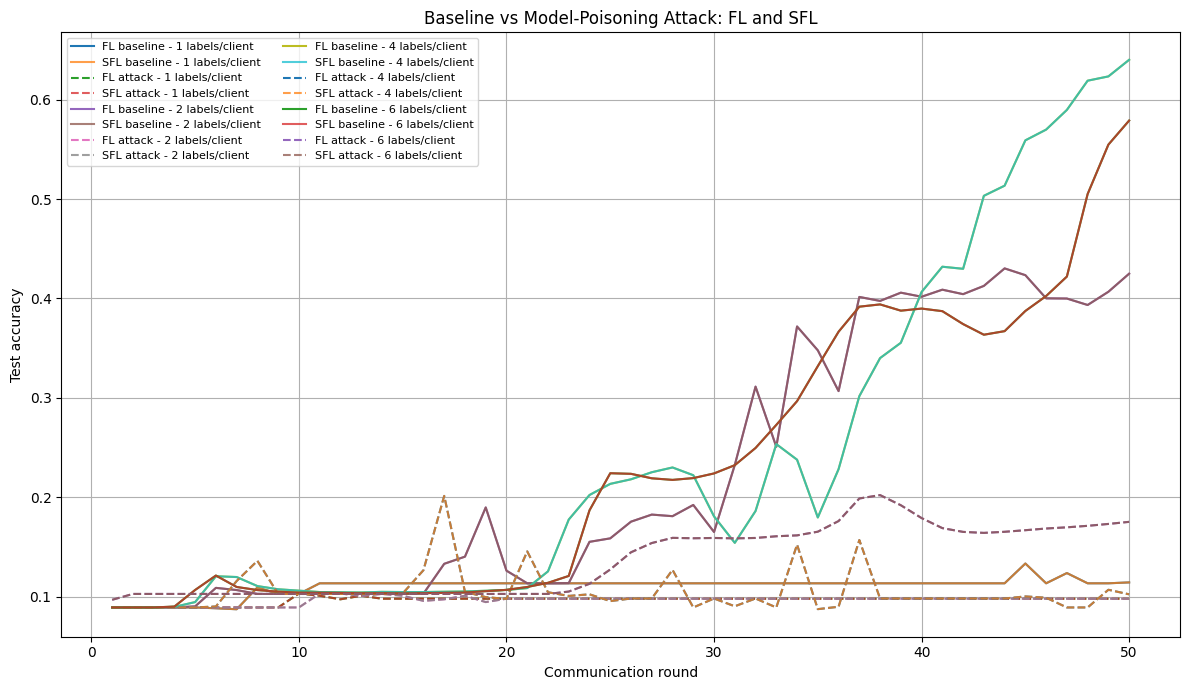

Saved accuracy comparison plot to: results/plots/fl_vs_sfl_mnist_poisoning_accuracy_baseline_vs_attack_50_rounds.png


In [39]:
accuracy_attack_plot_path = os.path.join(
    PLOTS_DIR,
    f"fl_vs_sfl_mnist_poisoning_accuracy_baseline_vs_attack_{ROUNDS}_rounds.png",
)

plt.figure(figsize=(12, 7))

for labels_per_client in LABELS_PER_CLIENT_LIST:
    for attack_enabled in scenario_flags:
        scen = scenario_name(attack_enabled)
        df = combined_results_df[
            (combined_results_df["labels_per_client"] == labels_per_client)
            & (combined_results_df["scenario"] == scen)
        ]

        suffix = "attack" if attack_enabled else "baseline"
        line_style = "--" if attack_enabled else "-"

        plt.plot(df["round"], df["fl_test_accuracy"], linestyle=line_style,
                 label=f"FL {suffix} - {labels_per_client} labels/client")
        plt.plot(df["round"], df["sfl_test_accuracy"], linestyle=line_style, alpha=0.75,
                 label=f"SFL {suffix} - {labels_per_client} labels/client")

plt.xlabel("Communication round")
plt.ylabel("Test accuracy")
plt.title("Baseline vs Model-Poisoning Attack: FL and SFL")
plt.grid(True)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(accuracy_attack_plot_path, dpi=200)
plt.show()

print("Saved accuracy comparison plot to:", accuracy_attack_plot_path)


## 18. Per-setting attack comparison plots

The previous combined graph can be busy. This cell creates one clearer accuracy plot for each labels/client setting.

These plots are usually easier to include in a report because each figure focuses on one level of non-IID severity.

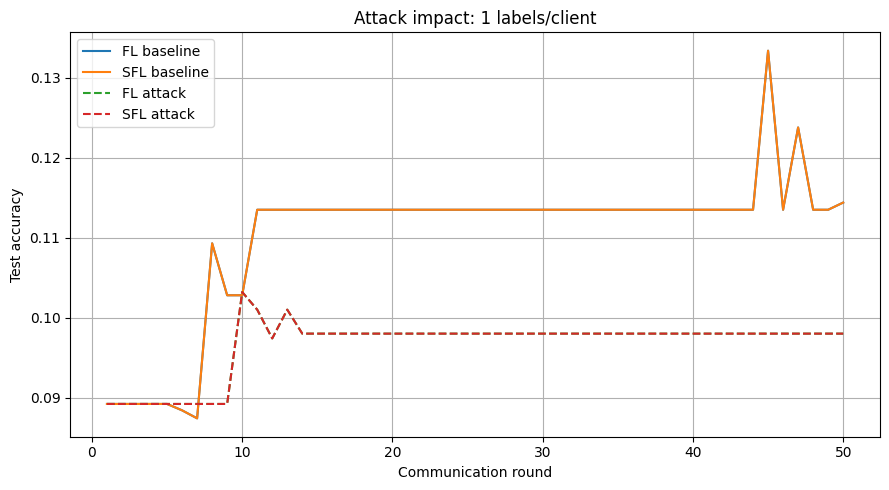

Saved: results/plots/fl_vs_sfl_mnist_poisoning_1_labels_per_client_accuracy_50_rounds.png


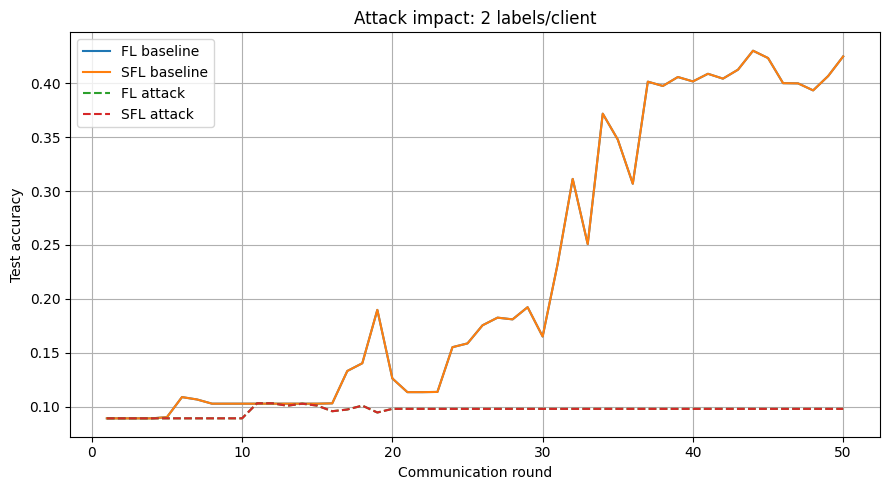

Saved: results/plots/fl_vs_sfl_mnist_poisoning_2_labels_per_client_accuracy_50_rounds.png


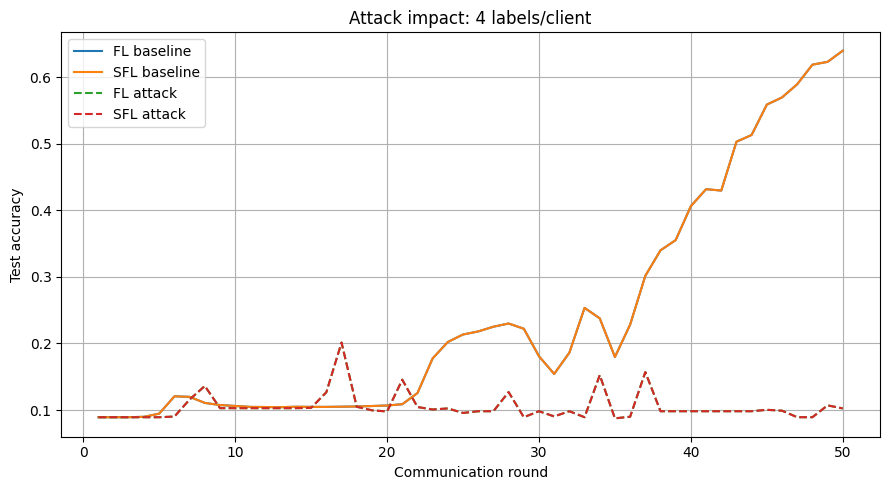

Saved: results/plots/fl_vs_sfl_mnist_poisoning_4_labels_per_client_accuracy_50_rounds.png


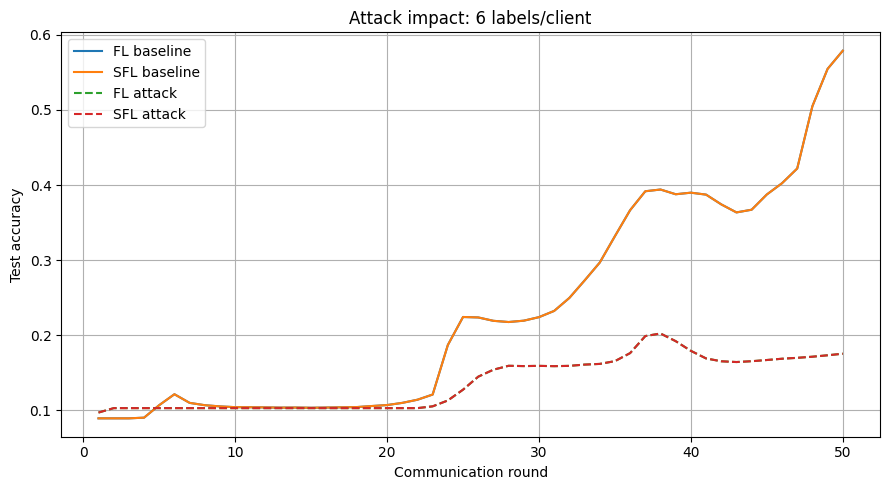

Saved: results/plots/fl_vs_sfl_mnist_poisoning_6_labels_per_client_accuracy_50_rounds.png


In [40]:
per_setting_attack_plot_paths = []

for labels_per_client in LABELS_PER_CLIENT_LIST:
    plot_path = os.path.join(
        PLOTS_DIR,
        f"fl_vs_sfl_mnist_poisoning_{labels_per_client}_labels_per_client_accuracy_{ROUNDS}_rounds.png",
    )
    per_setting_attack_plot_paths.append(plot_path)

    plt.figure(figsize=(9, 5))

    for attack_enabled in scenario_flags:
        scen = scenario_name(attack_enabled)
        df = combined_results_df[
            (combined_results_df["labels_per_client"] == labels_per_client)
            & (combined_results_df["scenario"] == scen)
        ]

        suffix = "attack" if attack_enabled else "baseline"
        line_style = "--" if attack_enabled else "-"

        plt.plot(df["round"], df["fl_test_accuracy"], linestyle=line_style, label=f"FL {suffix}")
        plt.plot(df["round"], df["sfl_test_accuracy"], linestyle=line_style, label=f"SFL {suffix}")

    plt.xlabel("Communication round")
    plt.ylabel("Test accuracy")
    plt.title(f"Attack impact: {labels_per_client} labels/client")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_path, dpi=200)
    plt.show()

    print("Saved:", plot_path)


## 19. Loss curves: baseline vs attack

Accuracy can sometimes hide instability. The loss curve shows whether the attacked model becomes less confident or fails to optimise properly.

A successful poisoning attack should generally increase loss and/or reduce accuracy compared with the baseline.

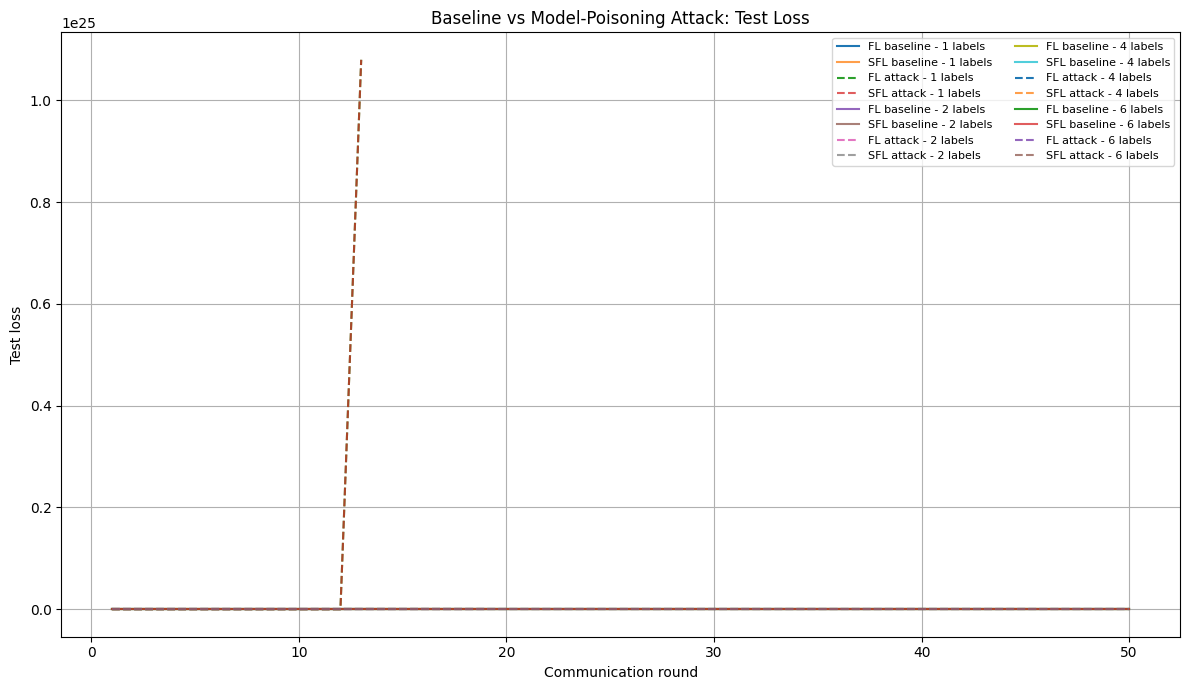

Saved loss comparison plot to: results/plots/fl_vs_sfl_mnist_poisoning_loss_baseline_vs_attack_50_rounds.png


In [41]:
loss_attack_plot_path = os.path.join(
    PLOTS_DIR,
    f"fl_vs_sfl_mnist_poisoning_loss_baseline_vs_attack_{ROUNDS}_rounds.png",
)

plt.figure(figsize=(12, 7))

for labels_per_client in LABELS_PER_CLIENT_LIST:
    for attack_enabled in scenario_flags:
        scen = scenario_name(attack_enabled)
        df = combined_results_df[
            (combined_results_df["labels_per_client"] == labels_per_client)
            & (combined_results_df["scenario"] == scen)
        ]

        suffix = "attack" if attack_enabled else "baseline"
        line_style = "--" if attack_enabled else "-"

        plt.plot(df["round"], df["fl_test_loss"], linestyle=line_style,
                 label=f"FL {suffix} - {labels_per_client} labels")
        plt.plot(df["round"], df["sfl_test_loss"], linestyle=line_style, alpha=0.75,
                 label=f"SFL {suffix} - {labels_per_client} labels")

plt.xlabel("Communication round")
plt.ylabel("Test loss")
plt.title("Baseline vs Model-Poisoning Attack: Test Loss")
plt.grid(True)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(loss_attack_plot_path, dpi=200)
plt.show()

print("Saved loss comparison plot to:", loss_attack_plot_path)


## 20. Final-round summary and attack impact table

This cell summarises the final round of every scenario.

It also calculates the **accuracy drop caused by the attack**:

`accuracy_drop = baseline_accuracy - attacked_accuracy`

A larger positive drop means the poisoning attack was more damaging.

In [42]:
final_summary_df = (
    combined_results_df
    .sort_values(["scenario", "labels_per_client", "round"])
    .groupby(["scenario", "labels_per_client"])
    .tail(1)
    [[
        "scenario", "attack_enabled", "labels_per_client", "round", "optimizer",
        "fl_test_accuracy", "sfl_test_accuracy", "fl_test_loss", "sfl_test_loss",
        "fl_minus_sfl_accuracy", "global_l2_distance_fl_vs_sfl", "weights_dir",
    ]]
    .reset_index(drop=True)
)

display(final_summary_df)

summary_csv_path = os.path.join(RESULTS_CSV_DIR, f"fl_vs_sfl_mnist_poisoning_final_summary_{ROUNDS}_rounds.csv")
final_summary_df.to_csv(summary_csv_path, index=False)
print("Saved final summary CSV to:", summary_csv_path)

impact_rows = []
for labels_per_client in LABELS_PER_CLIENT_LIST:
    baseline_row = final_summary_df[(final_summary_df["labels_per_client"] == labels_per_client) & (final_summary_df["scenario"] == scenario_name(False))].iloc[0]
    attack_row = final_summary_df[(final_summary_df["labels_per_client"] == labels_per_client) & (final_summary_df["scenario"] == scenario_name(True))].iloc[0]

    impact_rows.append({
        "labels_per_client": labels_per_client,
        "fl_baseline_final_accuracy": baseline_row["fl_test_accuracy"],
        "fl_attack_final_accuracy": attack_row["fl_test_accuracy"],
        "fl_accuracy_drop": baseline_row["fl_test_accuracy"] - attack_row["fl_test_accuracy"],
        "sfl_baseline_final_accuracy": baseline_row["sfl_test_accuracy"],
        "sfl_attack_final_accuracy": attack_row["sfl_test_accuracy"],
        "sfl_accuracy_drop": baseline_row["sfl_test_accuracy"] - attack_row["sfl_test_accuracy"],
        "baseline_l2_fl_vs_sfl": baseline_row["global_l2_distance_fl_vs_sfl"],
        "attack_l2_fl_vs_sfl": attack_row["global_l2_distance_fl_vs_sfl"],
    })

attack_impact_df = pd.DataFrame(impact_rows)
display(attack_impact_df)

impact_csv_path = os.path.join(RESULTS_CSV_DIR, f"fl_vs_sfl_mnist_poisoning_attack_impact_{ROUNDS}_rounds.csv")
attack_impact_df.to_csv(impact_csv_path, index=False)
print("Saved attack impact CSV to:", impact_csv_path)


,scenario,attack_enabled,labels_per_client,round,optimizer,fl_test_accuracy,sfl_test_accuracy,fl_test_loss,sfl_test_loss,fl_minus_sfl_accuracy,global_l2_distance_fl_vs_sfl,weights_dir
0,attack_client_0_scale_minus_5p0,True,1,50,SGD,0.0980,0.0980,NaN,NaN,0.0,NaN,results/weights/fl_vs_sfl_noniid_poisoning_att...
1,attack_client_0_scale_minus_5p0,True,2,50,SGD,0.0980,0.0980,NaN,NaN,0.0,NaN,results/weights/fl_vs_sfl_noniid_poisoning_att...
2,attack_client_0_scale_minus_5p0,True,4,50,SGD,0.1024,0.1024,297.408530,297.408530,0.0,0.0,results/weights/fl_vs_sfl_noniid_poisoning_att...
3,attack_client_0_scale_minus_5p0,True,6,50,SGD,0.1753,0.1753,3.002571,3.002571,0.0,0.0,results/weights/fl_vs_sfl_noniid_poisoning_att...
4,baseline_no_attack,False,1,50,SGD,0.1144,0.1144,2.295299,2.295299,0.0,0.0,results/weights/fl_vs_sfl_noniid_poisoning_att...
5,baseline_no_attack,False,2,50,SGD,0.4249,0.4249,1.744850,1.744850,0.0,0.0,results/weights/fl_vs_sfl_noniid_poisoning_att...
6,baseline_no_attack,False,4,50,SGD,0.6400,0.6400,1.153104,1.153104,0.0,0.0,results/weights/fl_vs_sfl_noniid_poisoning_att...
7,baseline_no_attack,False,6,50,SGD,0.5789,0.5789,1.355248,1.355248,0.0,0.0,results/weights/fl_vs_sfl_noniid_poisoning_att...


Saved final summary CSV to: results/csv/fl_vs_sfl_mnist_poisoning_final_summary_50_rounds.csv


,labels_per_client,fl_baseline_final_accuracy,fl_attack_final_accuracy,fl_accuracy_drop,sfl_baseline_final_accuracy,sfl_attack_final_accuracy,sfl_accuracy_drop,baseline_l2_fl_vs_sfl,attack_l2_fl_vs_sfl
0,1,0.1144,0.0980,0.0164,0.1144,0.0980,0.0164,0.0,NaN
1,2,0.4249,0.0980,0.3269,0.4249,0.0980,0.3269,0.0,NaN
2,4,0.6400,0.1024,0.5376,0.6400,0.1024,0.5376,0.0,0.0
3,6,0.5789,0.1753,0.4036,0.5789,0.1753,0.4036,0.0,0.0


Saved attack impact CSV to: results/csv/fl_vs_sfl_mnist_poisoning_attack_impact_50_rounds.csv


## 21. Attack impact bar chart

This chart shows the final-round accuracy drop caused by the malicious client.

This is one of the most useful figures for the report because it directly answers:

> How much did one poisoned client reduce the global model accuracy?

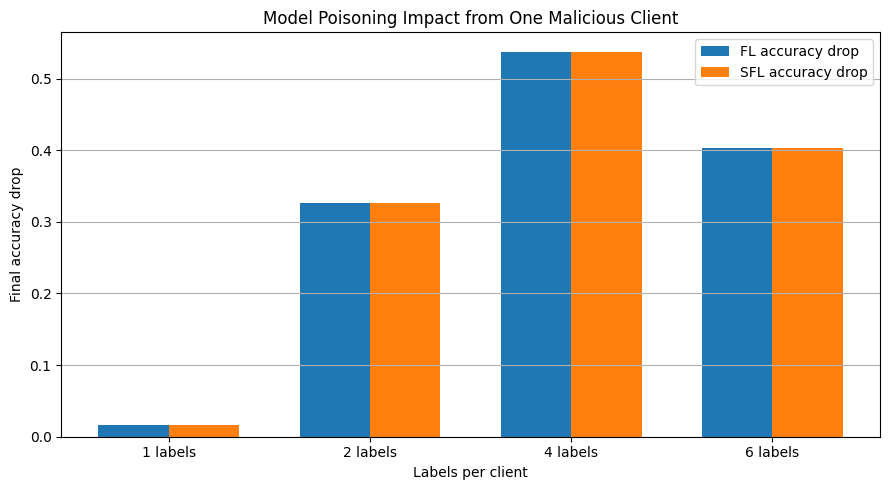

Saved attack impact bar chart to: results/plots/fl_vs_sfl_mnist_poisoning_accuracy_drop_bar_50_rounds.png


In [43]:
attack_impact_bar_path = os.path.join(PLOTS_DIR, f"fl_vs_sfl_mnist_poisoning_accuracy_drop_bar_{ROUNDS}_rounds.png")

x = np.arange(len(attack_impact_df))
width = 0.35

plt.figure(figsize=(9, 5))

# Positive values mean the attack reduced final accuracy.
plt.bar(x - width / 2, attack_impact_df["fl_accuracy_drop"], width, label="FL accuracy drop")
plt.bar(x + width / 2, attack_impact_df["sfl_accuracy_drop"], width, label="SFL accuracy drop")

plt.xticks(x, [f"{int(v)} labels" for v in attack_impact_df["labels_per_client"]])
plt.xlabel("Labels per client")
plt.ylabel("Final accuracy drop")
plt.title("Model Poisoning Impact from One Malicious Client")
plt.grid(True, axis="y")
plt.legend()
plt.tight_layout()
plt.savefig(attack_impact_bar_path, dpi=200)
plt.show()

print("Saved attack impact bar chart to:", attack_impact_bar_path)


## 22. FL/SFL equivalence check under baseline and attack

This plot checks whether FL and SFL remain equivalent when the same poisoning logic is applied.

If the L2 distance remains close to zero, it means the SFL Design 1 implementation is still matching the FL baseline/attack behaviour. This is important because your supervisor wanted a fair comparison between FL and SFL before moving to defence.

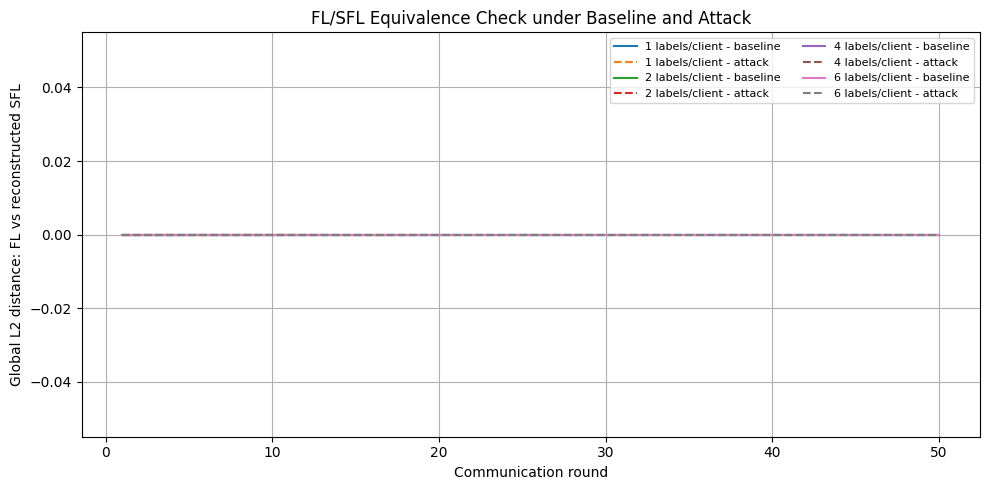

Saved L2 equivalence plot to: results/plots/fl_vs_sfl_mnist_poisoning_l2_equivalence_50_rounds.png


In [44]:
l2_attack_plot_path = os.path.join(PLOTS_DIR, f"fl_vs_sfl_mnist_poisoning_l2_equivalence_{ROUNDS}_rounds.png")

plt.figure(figsize=(10, 5))

for labels_per_client in LABELS_PER_CLIENT_LIST:
    for attack_enabled in scenario_flags:
        scen = scenario_name(attack_enabled)
        df = combined_results_df[(combined_results_df["labels_per_client"] == labels_per_client) & (combined_results_df["scenario"] == scen)]

        suffix = "attack" if attack_enabled else "baseline"
        line_style = "--" if attack_enabled else "-"

        plt.plot(df["round"], df["global_l2_distance_fl_vs_sfl"], linestyle=line_style,
                 label=f"{labels_per_client} labels/client - {suffix}")

plt.xlabel("Communication round")
plt.ylabel("Global L2 distance: FL vs reconstructed SFL")
plt.title("FL/SFL Equivalence Check under Baseline and Attack")
plt.grid(True)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(l2_attack_plot_path, dpi=200)
plt.show()

print("Saved L2 equivalence plot to:", l2_attack_plot_path)


## 23. Report-ready explanation and interpretation

This cell writes a report-ready Markdown section explaining:

- the baseline experiment,
- the poisoning attack,
- how the malicious client changes its update,
- how to interpret the accuracy drop,
- and why this prepares the project for the next defence stage.

In [45]:
report_text_lines = []
report_text_lines.append("# Report section: Model poisoning attack in FL and SFL")
report_text_lines.append("")
report_text_lines.append(
    f"This experiment compared Federated Learning (FL) and Split Federated Learning (SFL Design 1) on MNIST using {NUM_CLIENTS} clients over {ROUNDS} communication rounds. "
    f"The non-IID severity was varied using 1, 2, 4, and 6 labels per client. "
    f"The optimiser was {OPTIMIZER_NAME} with a base learning rate of {LEARNING_RATE}. "
    f"The global model was evaluated on the full MNIST test set after every aggregation round."
)
report_text_lines.append("")
report_text_lines.append("## Poisoning attack method")
report_text_lines.append(
    f"A model poisoning attack was introduced by selecting client {MALICIOUS_CLIENT_ID} as the malicious client. "
    "The malicious client still performed normal local training, so it appeared to behave like an honest participant during the local training phase. "
    "However, before aggregation, its submitted model update was modified."
)
report_text_lines.append("")
report_text_lines.append(
    "For an honest client, the local update is calculated as: `update = client_state - global_state`. "
    f"For the malicious client, the submitted state was changed to: `global_state + ({ATTACK_SCALE}) × update`. "
    "Because the attack scale is negative, the malicious client sends an update in the opposite direction of honest learning. "
    "Because the magnitude is greater than one, the harmful update is amplified before FedAvg aggregation."
)
report_text_lines.append("")
report_text_lines.append("## Final-round attack impact")

for _, row in attack_impact_df.iterrows():
    report_text_lines.append(
        f"- {int(row['labels_per_client'])} labels/client: "
        f"FL baseline accuracy = {row['fl_baseline_final_accuracy']:.4f}, "
        f"FL attacked accuracy = {row['fl_attack_final_accuracy']:.4f}, "
        f"FL accuracy drop = {row['fl_accuracy_drop']:.4f}; "
        f"SFL baseline accuracy = {row['sfl_baseline_final_accuracy']:.4f}, "
        f"SFL attacked accuracy = {row['sfl_attack_final_accuracy']:.4f}, "
        f"SFL accuracy drop = {row['sfl_accuracy_drop']:.4f}."
    )

report_text_lines.append("")
report_text_lines.append("## Interpretation")
report_text_lines.append(
    "The attack impact should be interpreted by comparing the baseline and attacked accuracy curves. "
    "If the attacked model has lower accuracy or higher loss than the baseline, the malicious update successfully degraded global learning. "
    "The one-label-per-client case may already perform close to random guessing, so the attack may not have much additional room to reduce accuracy. "
    "The 2, 4, and 6 labels/client cases are often more useful for measuring attack impact because the baseline model has more opportunity to learn before being damaged."
)
report_text_lines.append(
    "The global L2 distance between FL and reconstructed SFL remains an important equivalence check. "
    "If the L2 distance remains close to zero in both baseline and attack scenarios, it indicates that the SFL Design 1 implementation is behaving equivalently to FL under the same honest or poisoned update logic."
)
report_text_lines.append(
    "These results prepare the next stage of the project: defence. A defence method can now be evaluated by comparing three cases: no attack, attack without defence, and attack with defence. "
    "A successful defence should reduce the accuracy drop caused by the malicious client while preserving performance in the no-attack baseline."
)

report_text = "\n".join(report_text_lines)
report_ready_path = os.path.join(REPORT_DIR, f"fl_vs_sfl_mnist_poisoning_report_ready_section_{ROUNDS}_rounds.md")
with open(report_ready_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(report_text)
print("\nSaved report-ready section to:", report_ready_path)


# Report section: Model poisoning attack in FL and SFL

This experiment compared Federated Learning (FL) and Split Federated Learning (SFL Design 1) on MNIST using 10 clients over 50 communication rounds. The non-IID severity was varied using 1, 2, 4, and 6 labels per client. The optimiser was SGD with a base learning rate of 0.005. The global model was evaluated on the full MNIST test set after every aggregation round.

## Poisoning attack method
A model poisoning attack was introduced by selecting client 0 as the malicious client. The malicious client still performed normal local training, so it appeared to behave like an honest participant during the local training phase. However, before aggregation, its submitted model update was modified.

For an honest client, the local update is calculated as: `update = client_state - global_state`. For the malicious client, the submitted state was changed to: `global_state + (-5.0) × update`. Because the attack scale is negative, the malicious 

## 24. Output file locations

This final cell prints where all key outputs were saved:

- individual CSV files,
- combined CSV file,
- summary and attack impact CSV files,
- plots,
- model weights,
- and the report-ready Markdown section.

In [46]:
print("Per-setting/per-scenario CSV files:")
for labels_per_client in LABELS_PER_CLIENT_LIST:
    for attack_enabled in scenario_flags:
        scen = scenario_name(attack_enabled)
        print(" -", os.path.join(RESULTS_CSV_DIR, f"fl_vs_sfl_mnist_noniid_{labels_per_client}_labels_per_client_{scen}_{ROUNDS}_rounds.csv"))

print("\nCombined CSV:")
print(" -", combined_csv_path)

print("\nFinal summary CSV:")
print(" -", summary_csv_path)

print("\nAttack impact CSV:")
print(" -", impact_csv_path)

print("\nReport-ready Markdown:")
print(" -", report_ready_path)

print("\nPlots:")
for path in [accuracy_attack_plot_path, loss_attack_plot_path, attack_impact_bar_path, l2_attack_plot_path, *per_setting_attack_plot_paths]:
    print(" -", path)

print("\nWeights folders:")
for labels_per_client in LABELS_PER_CLIENT_LIST:
    for attack_enabled in scenario_flags:
        scen = scenario_name(attack_enabled)
        print(" -", os.path.join(WEIGHTS_BASE_DIR, f"labels_{labels_per_client}_per_client", scen))


Per-setting/per-scenario CSV files:
 - results/csv/fl_vs_sfl_mnist_noniid_1_labels_per_client_baseline_no_attack_50_rounds.csv
 - results/csv/fl_vs_sfl_mnist_noniid_1_labels_per_client_attack_client_0_scale_minus_5p0_50_rounds.csv
 - results/csv/fl_vs_sfl_mnist_noniid_2_labels_per_client_baseline_no_attack_50_rounds.csv
 - results/csv/fl_vs_sfl_mnist_noniid_2_labels_per_client_attack_client_0_scale_minus_5p0_50_rounds.csv
 - results/csv/fl_vs_sfl_mnist_noniid_4_labels_per_client_baseline_no_attack_50_rounds.csv
 - results/csv/fl_vs_sfl_mnist_noniid_4_labels_per_client_attack_client_0_scale_minus_5p0_50_rounds.csv
 - results/csv/fl_vs_sfl_mnist_noniid_6_labels_per_client_baseline_no_attack_50_rounds.csv
 - results/csv/fl_vs_sfl_mnist_noniid_6_labels_per_client_attack_client_0_scale_minus_5p0_50_rounds.csv

Combined CSV:
 - results/csv/fl_vs_sfl_mnist_noniid_poisoning_combined_50_rounds.csv

Final summary CSV:
 - results/csv/fl_vs_sfl_mnist_poisoning_final_summary_50_rounds.csv

Attack i